In [ ]:

from dataclasses import dataclass
from typing import Tuple, Optional, List

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from mlp import MLPForecaster

In [2]:
import sys
import os

# Add the parent directory to sys.path to allow importing model_utils
current_dir = os.path.dirname(os.path.abspath("__file__"))
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Alternative if running interactively and __file__ is not defined:
# sys.path.append(os.path.abspath('..'))
sys.path.append('..')


# Fold Index Generator

In [3]:
def walk_forward_splits(T, lookback, horizon, val_size, test_size, step, train_size=None):
    """
    Generates train/val splits by sliding forward from the beginning of the time series using a stride of `step`.
    Terminates when the validation window exceeds the available data (T - test_size).
    """
    cv_end = T - test_size
   
    if train_size is not None:
     
         current_train_end = train_size
    else:
         
         current_train_end = val_size

    # Loop forward
    while True:
        val_start = current_train_end
        val_end = val_start + val_size
        
        # Stop if the validation window goes into the held-out test set
        if val_end > cv_end:
            break
            
        train_end = val_start
        
        if train_size is not None:
             # Sliding: Fixed size window trailing the split point
             train_start = train_end - train_size
             # Safety check, though starting at train_size ensures >= 0
             if train_start < 0:
                 current_train_end += step
                 continue
        else:
             # Expanding: Fixed start at 0
             train_start = 0
             
        yield train_start, train_end, val_start, val_end
        
        # Move forward
        current_train_end += step

In [4]:
def make_windows(
    series: np.ndarray,
    lookback: int,
    horizon: int,
) -> Tuple[np.ndarray, np.ndarray]:

    series = np.asarray(series, dtype=np.float32)
    if series.ndim == 1:
        series = series[:, None]  # (T, 1)

    T, C = series.shape
    N = T - lookback - horizon + 1
    if N <= 0:
        raise ValueError("Time series too short for given lookback/horizon.")

    X = np.zeros((N, lookback, C), dtype=np.float32)
    y = np.zeros((N, horizon, C), dtype=np.float32)

    for i in range(N):
        X[i] = series[i : i + lookback]
        y[i] = series[i + lookback : i + lookback + horizon]

    return X, y


In [5]:
class WindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)  # (N, L, C)
        self.y = torch.from_numpy(y)  # (N, H, C)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [6]:
def build_loaders_for_fold(data, train_start, train_end, val_start, val_end,
                           cfg, target_channel, batch_size):

    train_data = data[train_start:train_end]

    scaler = RobustScaler()
    train_scaled = train_data.copy()
    train_scaled[:, target_channel:target_channel+1] = scaler.fit_transform(
        train_data[:, target_channel:target_channel+1]
    )

    # val context includes lookback before val_start
    start_idx = max(0, val_start)
    val_context = data[start_idx : val_end]
    val_scaled = val_context.copy()
    val_scaled[:, target_channel:target_channel+1] = scaler.transform(
        val_context[:, target_channel:target_channel+1]
    )

    X_train, y_train_full = make_windows(train_scaled, cfg.lookback, cfg.horizon)
    X_val,   y_val_full   = make_windows(val_scaled,  cfg.lookback, cfg.horizon)

    y_train = y_train_full[:, :, target_channel:target_channel+1]
    y_val   = y_val_full[:,   :, target_channel:target_channel+1]

    train_loader = DataLoader(WindowDataset(X_train, y_train),
                              batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(WindowDataset(X_val, y_val),
                              batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, scaler

In [8]:

DATA_PATH = '../dataset/subset_set.feather'
print(f"Loading data from {DATA_PATH}...")
df = pd.read_feather(DATA_PATH)

# Define constants
DATE_COL = 'date'
TARGET_COL = 'value'  

if DATE_COL in df.index.names:
    if DATE_COL in df.columns:
        
        df = df.reset_index(drop=True)
    else:
       
        df = df.reset_index()


if df.index.name == DATE_COL:
     df = df.reset_index(drop=True)
     

df = df.reset_index(drop=True)


df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL)
df = df.reset_index(drop=True) 


y = df[TARGET_COL]

print(len(y))
df['day_of_week'] = df[DATE_COL].dt.dayofweek
df['month'] = df[DATE_COL].dt.month
df['day_of_month'] = df[DATE_COL].dt.day
df['is_weekend'] = (df['day_of_week'] >= 5).astype(float)
df['is_christmas_day'] = ((df[DATE_COL].dt.month == 12) & (df[DATE_COL].dt.day == 25)).astype(float)
promo_cols = [col for col in df.columns if col.startswith('promo_')]
print(f"Found {len(promo_cols)} promotion columns: {promo_cols}")
for col in promo_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(float)

EXOG_COLS = ['day_of_week', 'month', 'day_of_month', 'is_weekend', 'is_christmas_day'] + promo_cols




Loading data from ../dataset/subset_set.feather...
7610
Found 16 promotion columns: ['promo_type_FRPG', 'promo_value_FRPG', 'promo_type_GAS', 'promo_value_GAS', 'promo_type_BOGO', 'promo_value_BOGO', 'promo_type_DISC', 'promo_value_DISC', 'promo_type_CIRC', 'promo_value_CIRC', 'promo_type_CIRE', 'promo_value_CIRE', 'promo_type_CLCP', 'promo_value_CLCP', 'promo_type_LFPE', 'promo_value_LFPE']


In [9]:
@dataclass
class TrainConfig:
    
    lookback: int = 30
    horizon: int = 153
    batch_size: int = 32
    train_size: int = 455
    val_size : int = 153
    lr: float = 1e-4
    epochs: int = 30
    weight_decay: float = 1e-3
    window_x: int = 30
    window_y: int = 10 
    step: int = 5
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
def train_model_with_loaders(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    loss_fn, 
    cfg, 
    seed, 
    product_id, 
    loss_type
):
    train_losses = []
    val_losses = []

    best_val = float("inf")
    best_state = None
    best_epoch = 0

    model_dir = f'best_models/seed_{seed}/{loss_type}'
    os.makedirs(model_dir, exist_ok=True)
    best_model_path = f'{model_dir}/mlp_product_{product_id}_fold.pth' # saved per fold ideally, or overwrite

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            #nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
        
        if len(train_loader.dataset) > 0:
            train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                pred = model(xb)
                val_loss += loss_fn(pred, yb).item() * xb.size(0)
        
        if len(val_loader.dataset) > 0:
            val_loss /= len(val_loader.dataset)
            val_losses.append(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch
                # torch.save(best_state, best_model_path) # Optional: save every fold best model
        
    return train_losses, val_losses, best_state, best_epoch, best_val

def run_sliding_window_validation(
    df: pd.DataFrame,
    cfg: TrainConfig,
    seed: int,
    loss_type: str,
    product_id: str,
    target_channel: int = 0,
    test_size: Optional[int] = None,
    hidden_sizes=(16, 8),
    target_col: str = "target",
    exog_cols: Optional[List[str]] = None,
    window_x: int = 400,
    window_y: int = 50,
    step_z: int = 30
):
    cols = [target_col] + (exog_cols if exog_cols else [])
    data = df[cols].values
    T = len(data)
    if test_size is None:
        test_size = cfg.val_size

    min_val_size = cfg.lookback + cfg.horizon
    if window_y < min_val_size:
        print(f"Adjusting window_y from {window_y} to {min_val_size} to allow at least 1 validation window.")
        window_y = min_val_size

    splits = list(walk_forward_splits(
        T=T, 
        lookback=cfg.lookback, 
        horizon=cfg.horizon, 
        val_size=window_y, 
        test_size=test_size, 
        step=step_z, 
        train_size=window_x
    ))

    print(f"Running Sliding Window Validation on {len(splits)} folds...")

    fold_results = []

    for k, (train_start, train_end, val_start, val_end) in enumerate(splits):
        print(f"Fold {k+1}/{len(splits)}: Train[{train_start}:{train_end}] Val[{val_start}:{val_end}]")

        train_loader, val_loader, scaler = build_loaders_for_fold(
            data, train_start, train_end, val_start, val_end,
            cfg, target_channel, cfg.batch_size
        )
        C_in = data.shape[1]

        model = MLPForecaster(
            lookback=cfg.lookback,
            in_channels=C_in,
            horizon=cfg.horizon,
            out_dim=1,
            hidden_sizes=hidden_sizes,
            dropout=0.2,
            activation="relu",
        ).to(cfg.device)

        # Optimizer & Loss
        opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        
        if loss_type.lower() == 'mse':
            loss_fn = nn.MSELoss()
        elif loss_type.lower() == 'mae':
            loss_fn = nn.L1Loss()
        elif loss_type.lower() == 'huber':
            loss_fn = nn.HuberLoss()
        else:
            loss_fn = nn.MSELoss()

        train_losses, val_losses, best_state, best_epoch, best_val = train_model_with_loaders(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=opt,
            loss_fn=loss_fn,
            cfg=cfg,
            seed=seed,
            product_id=f"{product_id}_fold{k}",
            loss_type=loss_type
        )
        
        print(f"  Best Val Loss: {best_val:.6f} (Epoch {best_epoch})")

        fold_results.append({
            "fold": k,
            "train_start": train_start,
            "train_end": train_end,
            "val_start": val_start,
            "val_end": val_end,
            "best_val_loss": best_val,
            "best_epoch": best_epoch,
            "last_train_loss": train_losses[-1] if train_losses else None,
            "model_state": best_state
        })

    # Aggregate results
    avg_val_loss = np.mean([r["best_val_loss"] for r in fold_results])
    print(f"\nAverage Validation Loss across {len(splits)} folds: {avg_val_loss:.6f}")

    return fold_results, avg_val_loss

In [ ]:
def train_mlp_forecaster(
    df: pd.DataFrame, 
    cfg: TrainConfig,
    seed: int,
    loss_type: str,
    product_id: str,
    target_channel: int = 0,    
    val_ratio: float = 0.2, 
    hidden_sizes=(16, 8),
    target_col: str = "target",
    exog_cols: Optional[List[str]] = None,
    test_size: Optional[int] = None,
    cv: bool = False,
    cv_step: int = 30,
    window_x: int = 400,
    window_y: int = 50,
    plot_folds: bool = True, # <--- Added argument
    date_col: str = 'date'    # <--- Added argument
):
    """
    Trains MLP Forecaster.
    If cv=True, performs sliding window validation (Cross-Validation).
    If cv=False, performs fixed train/val split.
    """
    
    cols = [target_col] + (exog_cols if exog_cols else [])
    data = df[cols].values
    C_in = len(cols)
    T = len(data)

    # Initialize model helper
    def get_model():
        m = MLPForecaster(
            lookback=cfg.lookback,
            in_channels=C_in,
            horizon=cfg.horizon,
            out_dim=1, 
            hidden_sizes=hidden_sizes,
            dropout=0.2,
            activation="relu",
        ).to(cfg.device)
        return m
    if loss_type.lower() == 'mse':
        loss_fn = nn.MSELoss()
    elif loss_type.lower() == 'mae':
        loss_fn = nn.L1Loss()
    elif loss_type.lower() == 'huber':
        loss_fn = nn.HuberLoss()
    else:
        loss_fn = nn.MSELoss()

    if cv:
        print(f"Running Sliding Window Validation (Step={cv_step}, Train Window={window_x}, Val Window={window_y})...")
        if test_size is None:
            test_size_actual = cfg.horizon
        else:
            test_size_actual = test_size

        # Fix: Ensure window_y is large enough to create at least one window
        min_val_size = cfg.lookback + cfg.horizon
        if window_y < min_val_size:
            print(f"Adjusting window_y from {window_y} to {min_val_size} to allow at least 1 validation window.")
            window_y = min_val_size

        splits = list(walk_forward_splits(
            T=T, 
            lookback=cfg.lookback, 
            horizon=cfg.horizon, 
            val_size=window_y, 
            test_size=test_size_actual, 
            step=cv_step, 
            train_size=window_x
        ))
        
        results = []
        
        most_recent_model = None
        most_recent_scaler = None
        most_recent_metrics = ([], [], 0) # train, val, epoch

        all_val_losses = []

        for i, (train_start, train_end, val_start, val_end) in enumerate(splits):
            print(f"Fold {i+1}/{len(splits)}: Train[{train_start}:{train_end}] Val[{val_start}:{val_end}]")
            
            # Sanity check for user
            train_len = train_end - train_start
            print(f"  > Training Window Size: {train_len} timesteps")
            
            train_loader, val_loader, scaler = build_loaders_for_fold(
                data, train_start, train_end, val_start, val_end,
                cfg, target_channel, cfg.batch_size
            )
            
            model = get_model()
            
            if loss_type.lower() == 'mse':
                loss_fn = nn.MSELoss()
            elif loss_type.lower() == 'mae':
                loss_fn = nn.L1Loss()
            elif loss_type.lower() == 'huber':
                loss_fn = nn.HuberLoss()
            else:
                loss_fn = nn.MSELoss()

            opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

            t_loss, v_loss, best_state, best_epoch, best_val = train_model_with_loaders(
                 model, train_loader, val_loader, opt, loss_fn, cfg, seed, f"{product_id}_fold_{i}", loss_type
            )
            
            print(f"  Fold {i+1} Best Val Loss: {best_val:.6f} at Epoch {best_epoch}")
            all_val_losses.append(v_loss)
            
            # --- PLOT FOLD ---
            if plot_folds and best_state is not None:
                model.load_state_dict(best_state)
                model.eval()
                
                fold_preds = []
                fold_targets = []
                with torch.no_grad():
                    for xb, yb in val_loader:
                        preds = model(xb.to(cfg.device)).cpu().numpy()
                        fold_preds.append(preds[:, :, 0]) # Assuming shape (B, H, 1)
                        fold_targets.append(yb.numpy()[:, :, 0])
                
                if len(fold_preds) > 0:
                    fold_preds = np.concatenate(fold_preds, axis=0)
                    fold_targets = np.concatenate(fold_targets, axis=0)
                    
                    # Unscale
                    fold_preds_unscaled = scaler.inverse_transform(fold_preds.reshape(-1, 1)).reshape(fold_preds.shape)
                    fold_targets_unscaled = scaler.inverse_transform(fold_targets.reshape(-1, 1)).reshape(fold_targets.shape)
                    
                    # Simple plot of the first prediction in the batch vs target over the horizon
                    plt.figure(figsize=(10, 4))
                    # Plot the first horizon window of the validation set
                    plt.plot(fold_targets_unscaled[0], label='Actual', marker='o')
                    plt.plot(fold_preds_unscaled[0], label='Predicted', marker='x')
                    plt.title(f'Fold {i+1} Validation (First Window) - Product {product_id}')
                    plt.xlabel('Horizon Step')
                    plt.ylabel(target_col)
                    plt.legend()
                    plt.grid(True)
                    plt.show()
            # -----------------
            
            # --- PLOT ENTIRE SERIES SPLIT ---
            plt.figure(figsize=(12, 4))
            full_series = df[target_col].values
            x_axis = np.arange(len(full_series))
            
            # Plot full series usually not needed if we cover everything, but cuts might exist.
            # Just plot train and val segments
            plt.plot(x_axis[train_start:train_end], full_series[train_start:train_end], color='blue', label='Train')
            plt.plot(x_axis[val_start:val_end], full_series[val_start:val_end], color='orange', label='Validation')
            
            plt.title(f'Fold {i+1} Train/Validation Split - Product {product_id}')
            plt.xlabel('Time Index')
            plt.ylabel(target_col)
            plt.legend()
            plt.grid(True)
            plt.show()
            # -----------------

            # Capture if this is the first (most recent) fold
            if i == 0:
                most_recent_model = model
                if best_state is not None:
                    most_recent_model.load_state_dict(best_state)
                most_recent_scaler = scaler
                most_recent_metrics = (t_loss, v_loss, best_epoch)

        avg_val = np.mean([min(vl) for vl in all_val_losses if vl])
        print(f"Average Best Val Loss across {len(splits)} folds: {avg_val:.6f}")

        # Return the most recent model (Fold 0)
        return most_recent_model, most_recent_scaler, most_recent_metrics[0], most_recent_metrics[1], most_recent_metrics[2]

    else:
        # Fixed Split Strategy (Original Logic)
        print("Running Fixed Split Train/Val...")
        
        test_start_idx = -test_size if test_size is not None else -cfg.horizon
        val_end_idx = test_start_idx
        val_start_idx = val_end_idx - cfg.val_size
        train_end_idx = val_start_idx 
        
        # If train_size is specified in config, apply it here too for consistency?
        # Standard "fixed split" usually implies expanding window (start=0), 
        # but if user asked for sliding, we should respect train_size if possible.
        if cfg.train_size is not None and cfg.train_size > 0:
             train_start_idx = max(0, train_end_idx - cfg.train_size)
             print(f"  > Sliding Train Window: [{train_start_idx} : {train_end_idx}] ({train_end_idx - train_start_idx} steps)")
             train_data_slice = data[train_start_idx:train_end_idx]
        else:
             print(f"  > Expanding Train Window: [0 : {train_end_idx}] ({train_end_idx} steps)")
             train_data_slice = data[:train_end_idx]
        
        scaler = RobustScaler()
        train_scaled = train_data_slice.copy()
        train_scaled[:, target_channel:target_channel+1] = scaler.fit_transform(
            train_data_slice[:, target_channel:target_channel+1]
        )
        
        val_context_data = data[val_start_idx : val_end_idx]
        val_scaled = val_context_data.copy()
        val_scaled[:, target_channel:target_channel+1] = scaler.transform(
            val_context_data[:, target_channel:target_channel+1]
        )

        X_train, y_train_full = make_windows(train_scaled, cfg.lookback, cfg.horizon)
        X_val, y_val_full = make_windows(val_scaled, cfg.lookback, cfg.horizon)

        y_train = y_train_full[:, :, target_channel : target_channel + 1]
        y_val = y_val_full[:, :, target_channel : target_channel + 1]

        train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=cfg.batch_size, shuffle=True)
        val_loader = DataLoader(WindowDataset(X_val, y_val), batch_size=cfg.batch_size, shuffle=False)
        
        model = get_model()

        if loss_type.lower() == 'mse':
            loss_fn = nn.MSELoss()
        elif loss_type.lower() == 'mae':
            loss_fn = nn.L1Loss()
        elif loss_type.lower() == 'huber':
            loss_fn = nn.HuberLoss()
        else:
            loss_fn = nn.MSELoss()

        opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        
        t_loss, v_loss, best_state, best_epoch, best_val = train_model_with_loaders(
             model, train_loader, val_loader, opt, loss_fn, cfg, seed, product_id, loss_type
        )
        
        if best_state is not None:
            model.load_state_dict(best_state)
            
        print(f"Fixed Split Best Val: {best_val:.6f} (Epoch {best_epoch})")
        
        return model, scaler, t_loss, v_loss, best_epoch

In [12]:

def recursive_forecast(
    model: MLPForecaster,
    scaler: RobustScaler,
    recent_history: np.ndarray,  
    future_exog: np.ndarray,     
    target_channel: int = 0,
    device: Optional[str] = None,
) -> np.ndarray:
    """
    Recursively forecasts `horizon` steps using a 1-step-ahead model.
    Uses known `future_exog` for the next step's input.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    
    horizon = len(future_exog)
    

    recent_history = np.asarray(recent_history, dtype=np.float32)
    if recent_history.ndim == 1:
        recent_history = recent_history[:, None]

    current_x_scaled = recent_history.copy()
    current_x_scaled[:, target_channel:target_channel+1] = scaler.transform(
        recent_history[:, target_channel:target_channel+1]
    )
    
    preds_scaled = []
    model = model.to(device).eval()

    input_window = current_x_scaled.copy()
    
    for i in range(horizon):

        x_tensor = torch.from_numpy(input_window).float().unsqueeze(0).to(device) # (1, L, C_in)
        y_pred = model(x_tensor)
        val_pred = y_pred.item()
        preds_scaled.append(val_pred)

        input_window = np.roll(input_window, -1, axis=0)
        
        input_window[-1, target_channel] = val_pred
        
        input_window[-1, 1:] = future_exog[i]
        
    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    
    preds = scaler.inverse_transform(preds_scaled).flatten()
    return preds



Found 10 products: [ 26008 921558 213626 213625 213624 213628 213629 213630 213631 514230]

########################################
Processing Product ID: 26008
########################################

>> Training Recursive Model (1-step ahead)...

==================== SEED 42 (Product 26008) ====================
Running Sliding Window Validation (Step=30, Train Window=150, Val Window=30)...
Adjusting window_y from 30 to 31 to allow at least 1 validation window.
Fold 1/15: Train[0:150] Val[150:181]
  > Training Window Size: 150 timesteps
  Fold 1 Best Val Loss: 0.000000 at Epoch 129


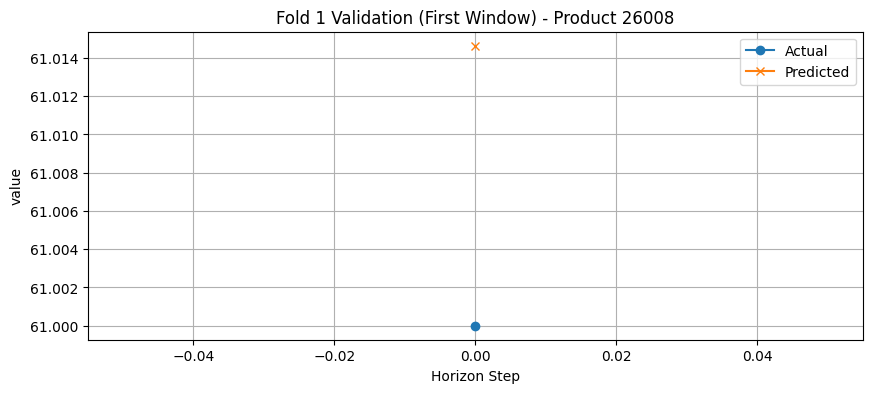

Fold 2/15: Train[30:180] Val[180:211]
  > Training Window Size: 150 timesteps
  Fold 2 Best Val Loss: 0.000000 at Epoch 973


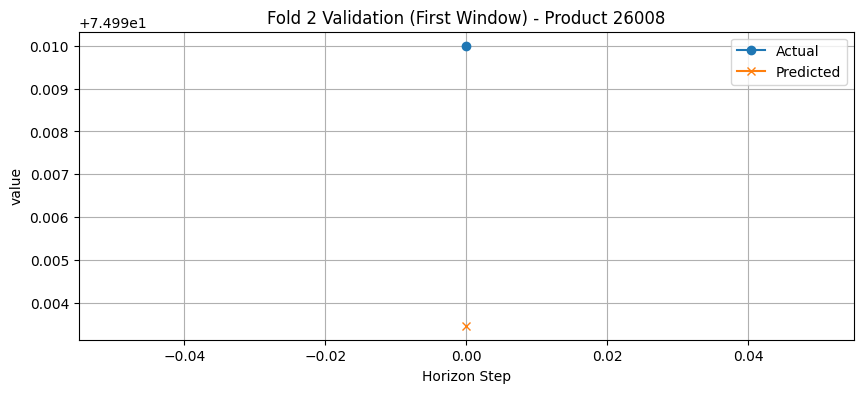

Fold 3/15: Train[60:210] Val[210:241]
  > Training Window Size: 150 timesteps
  Fold 3 Best Val Loss: 0.133646 at Epoch 155


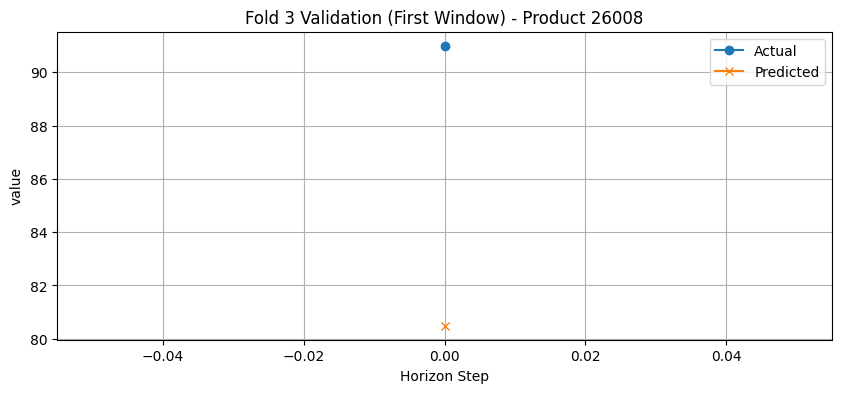

Fold 4/15: Train[90:240] Val[240:271]
  > Training Window Size: 150 timesteps
  Fold 4 Best Val Loss: 0.013739 at Epoch 1


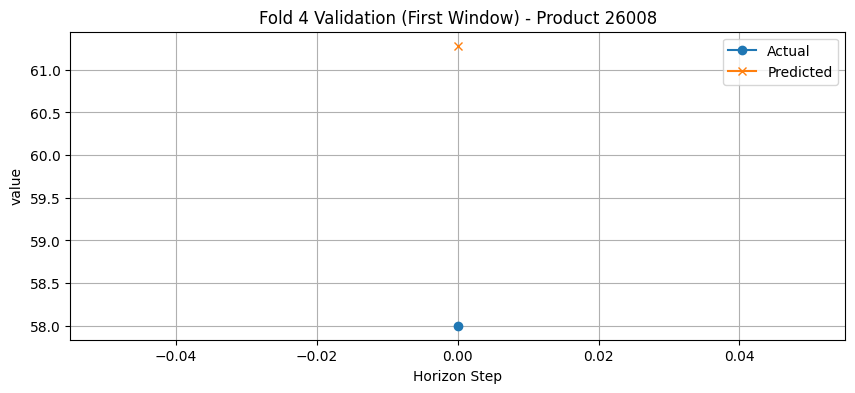

Fold 5/15: Train[120:270] Val[270:301]
  > Training Window Size: 150 timesteps
  Fold 5 Best Val Loss: 0.449956 at Epoch 970


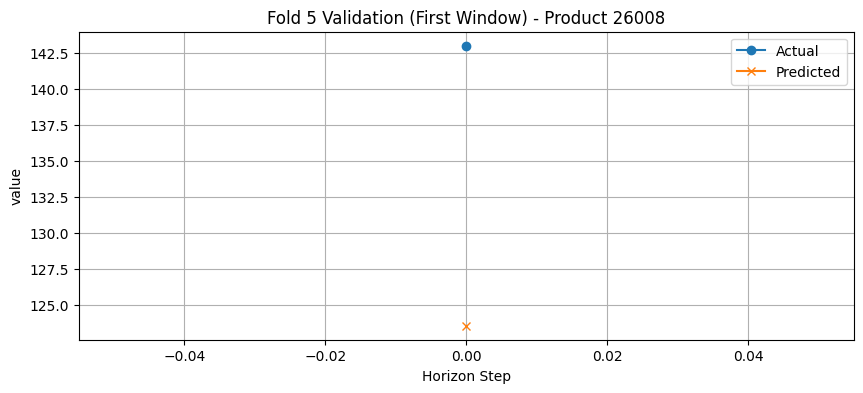

Fold 6/15: Train[150:300] Val[300:331]
  > Training Window Size: 150 timesteps
  Fold 6 Best Val Loss: 0.188044 at Epoch 769


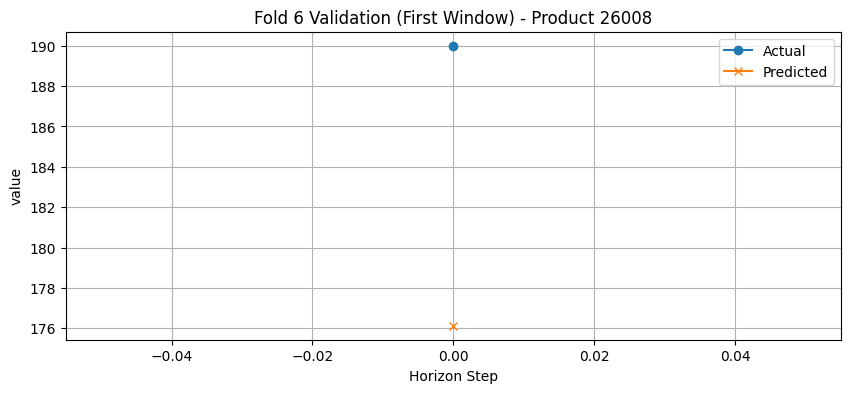

Fold 7/15: Train[180:330] Val[330:361]
  > Training Window Size: 150 timesteps
  Fold 7 Best Val Loss: 0.000000 at Epoch 245


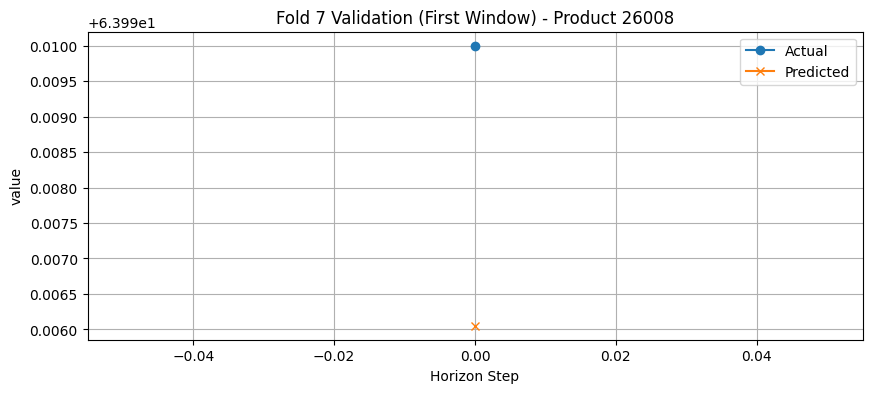

Fold 8/15: Train[210:360] Val[360:391]
  > Training Window Size: 150 timesteps
  Fold 8 Best Val Loss: 0.000008 at Epoch 850


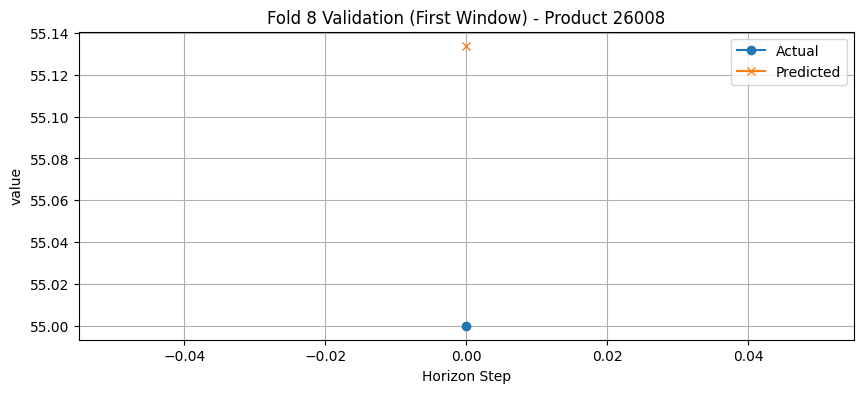

Fold 9/15: Train[240:390] Val[390:421]
  > Training Window Size: 150 timesteps
  Fold 9 Best Val Loss: 0.000000 at Epoch 352


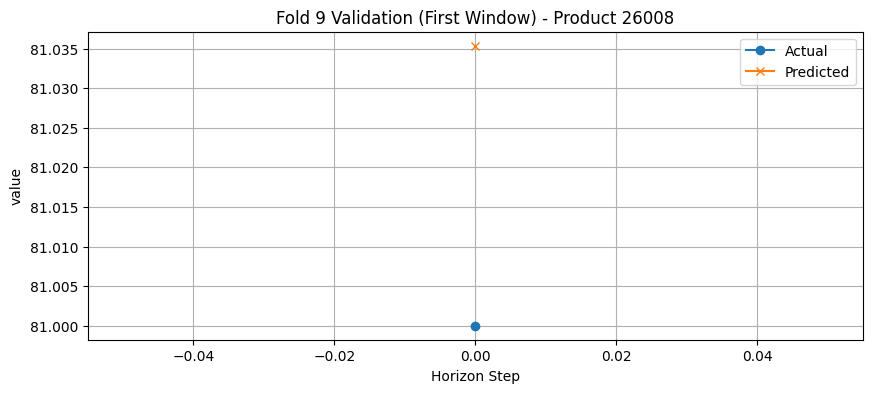

Fold 10/15: Train[270:420] Val[420:451]
  > Training Window Size: 150 timesteps
  Fold 10 Best Val Loss: 0.062309 at Epoch 937


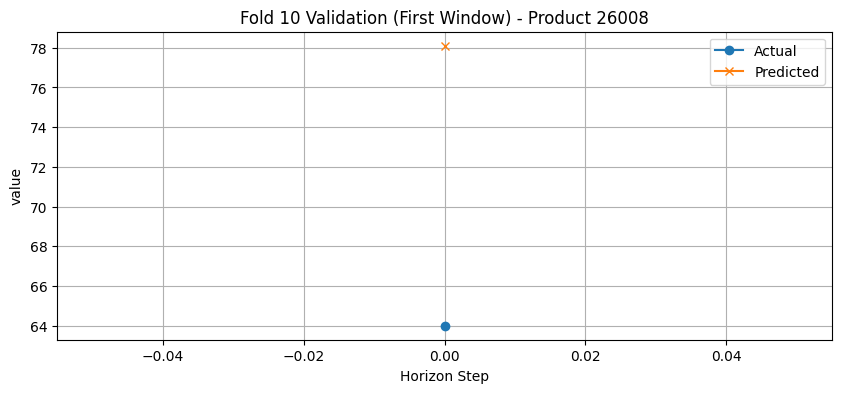

Fold 11/15: Train[300:450] Val[450:481]
  > Training Window Size: 150 timesteps


KeyboardInterrupt: 

In [13]:
from model_utils.plots import plot_results
import os
import matplotlib.pyplot as plt

seeds = [42, 123, 2024]
FEATURE_COLS = [TARGET_COL] + EXOG_COLS

# Create base output directory for plots
base_output_dir = "product_forecasts_recursive_slidingwindow"
os.makedirs(base_output_dir, exist_ok=True)

# 1. Identify all products
# Check column name again just in case
id_col = 'item_id' if 'item_id' in df.columns else 'id' 
product_ids = df[id_col].unique()
print(f"Found {len(product_ids)} products: {product_ids}")

for product_id in product_ids:
    print(f"\n{'#'*40}")
    print(f"Processing Product ID: {product_id}")
    print(f"{'#'*40}")
    
    # Filter data for this product
    product_df = df[df[id_col] == product_id].copy()
    product_df = product_df.sort_values(DATE_COL).reset_index(drop=True)
        
    # -------------------------------------------------------------------------
    # Recursive Step-by-Step Forecasting (Iterative)
    # -------------------------------------------------------------------------
    print("\n>> Training Recursive Model (1-step ahead)...")
    cfg_recursive = TrainConfig(
            lookback=30,
            horizon=1,   # Train to predict 1 step
            batch_size=32,
            train_size=453,
            val_size=153, 
            lr=1e-4,
            epochs=1000, 
            weight_decay=1e-3,
        )    
    # Prepare data splits for plotting (Indices)
    # Based on TrainConfig: val_size=153, test_size=153
    test_size = 153
    val_size = 153
    
    # Slices
    test_slice = slice(-test_size, None)
    val_slice = slice(-(test_size + val_size), -test_size)
    train_slice = slice(None, -(test_size + val_size))
    
    # Dates
    train_index = product_df[DATE_COL].iloc[train_slice]
    val_index = product_df[DATE_COL].iloc[val_slice]
    test_index = product_df[DATE_COL].iloc[test_slice]
    
    # Values (Target)
    train_values = product_df[TARGET_COL].iloc[train_slice].values
    val_values = product_df[TARGET_COL].iloc[val_slice].values
    test_values = product_df[TARGET_COL].iloc[test_slice].values
    
    test_start_idx = -test_size
    history_start_idx = test_start_idx - cfg_recursive.lookback 
    
    # Get history for [Target, Exog...]
    recent_history_df = product_df[FEATURE_COLS].iloc[history_start_idx : test_start_idx]
    recent_history = recent_history_df.values

    for seed in seeds:
        print(f"\n{'='*20} SEED {seed} (Product {product_id}) {'='*20}")
        
        # Create seed-specific directory
        seed_dir = os.path.join(base_output_dir, f"seed_{seed}")
        os.makedirs(seed_dir, exist_ok=True)

        REQ_VAL_SIZE = cfg_recursive.lookback + cfg_recursive.horizon
        if cfg_recursive.val_size < REQ_VAL_SIZE:
             # Dynamically adjust to ensure code runs
             print(f"Adjusting val_size from {cfg_recursive.val_size} to {REQ_VAL_SIZE} to ensure 1 window.")
             cfg_recursive.val_size = REQ_VAL_SIZE
        
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        model_recursive, scaler_recursive, train_loss_r, val_loss_r, best_epoch_r = train_mlp_forecaster(
            product_df, 
            cfg_recursive, 
            seed=seed,
            loss_type='mse',
            product_id=product_id,
            target_channel=0,
            hidden_sizes=(32,16),
            target_col=TARGET_COL,
            exog_cols=EXOG_COLS,
            test_size=153,
            cv=True,
            cv_step=30,         # z step
            window_x=150,       # x training values (slidable window size)
            window_y=30         # y validation values
        )
        
        # Forecast Recursive
        # We need FUTURE Exogenous variables for the forecast horizon
        future_exog_df = product_df[EXOG_COLS].iloc[test_start_idx:]
        future_exog = future_exog_df.values
        
        if len(future_exog) != 153:
            future_exog = future_exog[:153]

        pred_recursive = recursive_forecast(
            model_recursive,
            scaler_recursive,
            recent_history, 
            future_exog,    
            target_channel=0
        )

        rmse_recursive = np.sqrt(mean_squared_error(test_values, pred_recursive))
        mae_recursive = mean_absolute_error(test_values, pred_recursive)
        
        print(f"\nResults for Product {product_id} - Seed {seed}:")
        print(f"Recursive: RMSE={rmse_recursive:.4f}, MAE={mae_recursive:.4f}")
        
        plot_results(
            train_values, val_values, test_values, pred_recursive,
            train_index, val_index, test_index,
            train_loss_r, val_loss_r,
            target_col=TARGET_COL,
            title=f'MLP Recursive Forecast (Prod {product_id}, Seed {seed}) - RMSE: {rmse_recursive:.2f} (Best Epoch: {best_epoch_r})',
            save_path=os.path.join(seed_dir, f"recursive_forecast_prod_{product_id}.png")
        )

        print(f"Saved plots to {seed_dir}")